# Inter-Annotator Agreement — Ethnicity

Computes raw agreement, Cohen's κ, and Krippendorff's α between annotators on the ethnicity inference labels.

In [6]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
import krippendorff
import matplotlib.pyplot as plt

In [7]:
LEEN_PATH = "../../../data/ethnicity_inference/manual_labels_v1_leen.csv"
V2_PATH   = "../../../data/ethnicity_inference/manual_labels_v2.csv"

leen = pd.read_csv(LEEN_PATH)[["sample_index", "manual_label"]].rename(columns={"manual_label": "label_leen"})
v2   = pd.read_csv(V2_PATH)[["sample_index", "manual_label"]].rename(columns={"manual_label": "label_v2"})

df = leen.merge(v2, on="sample_index")

# Exclude items where either annotator skipped
df = df[(df["label_leen"] != "skip") & (df["label_v2"] != "skip")].copy()

print(f"Items after merging (excl. skips): {len(df)}")
print()
print("Leen label distribution:")
print(df["label_leen"].value_counts())
print()
print("v2 label distribution:")
print(df["label_v2"].value_counts())

Items after merging (excl. skips): 100

Leen label distribution:
label_leen
White                        62
Hispanic or Latino           14
Asian                        13
Unknown                       6
Black or African American     5
Name: count, dtype: int64

v2 label distribution:
label_v2
White                        39
Black or African American    20
Hispanic or Latino           17
Unknown                      13
Asian                        11
Name: count, dtype: int64


In [8]:
# ── 1. Raw agreement ────────────────────────────────────────────────────────
agreed = (df["label_leen"] == df["label_v2"]).sum()
N = len(df)
p_raw = agreed / N

# ── 2. Cohen's kappa ────────────────────────────────────────────────────────
kappa = cohen_kappa_score(df["label_leen"], df["label_v2"])

# ── 3. Krippendorff's alpha ─────────────────────────────────────────────────
categories = sorted(set(df["label_leen"]) | set(df["label_v2"]))
cat2int = {c: i for i, c in enumerate(categories)}

reliability_data = [
    df["label_leen"].map(cat2int).tolist(),
    df["label_v2"].map(cat2int).tolist(),
]
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement="nominal")

print(f"N items:              {N}")
print(f"Items agreed:         {agreed}")
print()
print(f"Raw agreement (p):    {p_raw:.4f}")
print(f"Cohen's kappa (κ):    {kappa:.4f}")
print(f"Krippendorff's α:     {alpha:.4f}")

N items:              100
Items agreed:         64

Raw agreement (p):    0.6400
Cohen's kappa (κ):    0.4874
Krippendorff's α:     0.4747


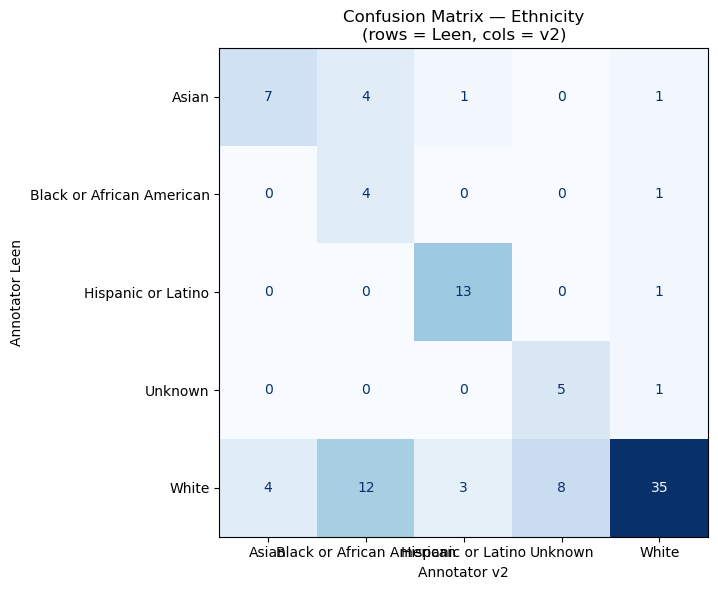

In [9]:
cm = confusion_matrix(df["label_leen"], df["label_v2"], labels=categories)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Ethnicity\n(rows = Leen, cols = v2)")
ax.set_xlabel("Annotator v2")
ax.set_ylabel("Annotator Leen")
plt.tight_layout()
plt.show()

In [10]:
disagreements = df[df["label_leen"] != df["label_v2"]].copy()
print(f"Total disagreements: {len(disagreements)}")
disagreements[["sample_index", "label_leen", "label_v2"]]

Total disagreements: 36


,sample_index,label_leen,label_v2
0,0,White,Unknown
4,4,White,Asian
5,5,White,Black or African American
6,6,White,Black or African American
10,10,Black or African American,White
14,14,White,Unknown
18,18,Unknown,White
19,19,White,Black or African American
20,20,Asian,Black or African American
27,27,White,Unknown
